In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [11]:
# 1. Membaca Gambar
img = Image.open("Surdik.JPG").convert("L")
img = np.array(img)

In [12]:
# 2. Histogram Sebelum
hist_before = np.zeros(256)

for pixel in img.flatten():
    hist_before[pixel] += 1


In [13]:
# 3. Histogram Normalization
min_val = img.min()
max_val = img.max()

norm_img = ((img - min_val) / (max_val - min_val)) * 255
norm_img = norm_img.astype(np.uint8)
hist_norm = np.zeros(256)

for pixel in norm_img.flatten():
    hist_norm[pixel] += 1

In [14]:
# 4. Histogram Equalization
hist = np.zeros(256)

for pixel in norm_img.flatten():
    hist[pixel] += 1

prob = hist / hist.sum()

cdf = np.cumsum(prob)

equalized = np.zeros_like(norm_img)

for i in range(norm_img.shape[0]):
    for j in range(norm_img.shape[1]):
        equalized[i,j] = int(cdf[norm_img[i,j]] * 255)

hist_eq = np.zeros(256)

for pixel in equalized.flatten():
    hist_eq[pixel] += 1

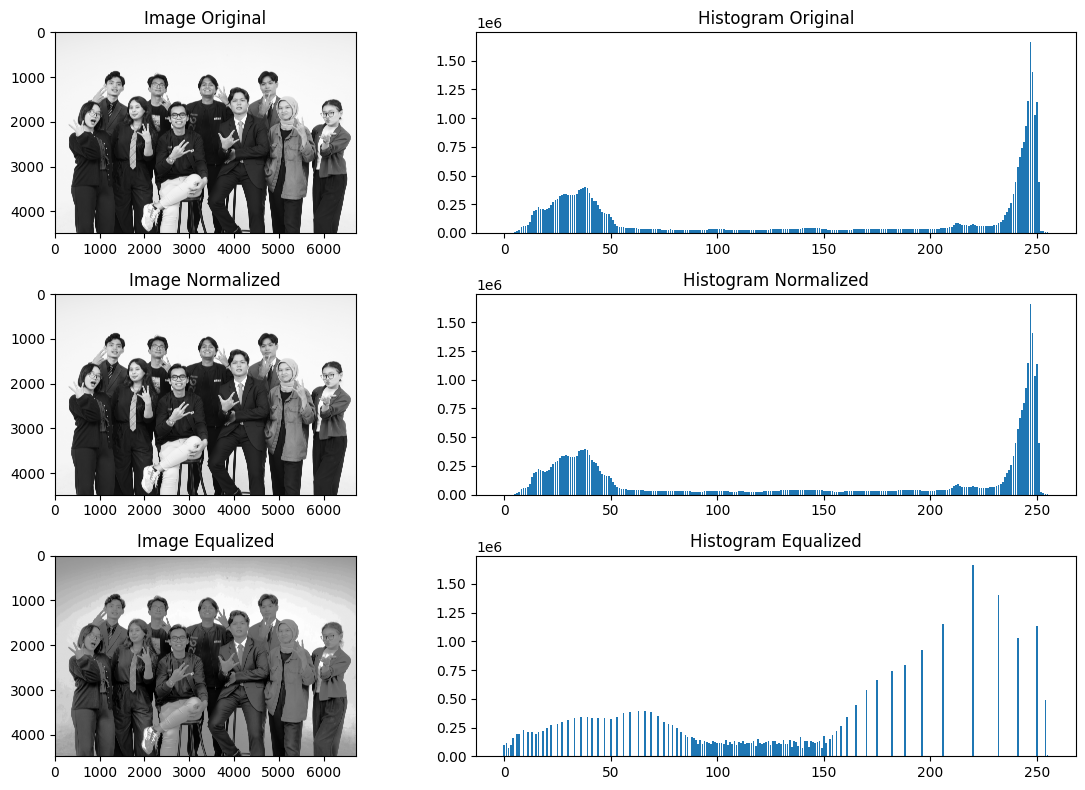

In [15]:
# 5. Menampilkan Hasil
plt.figure(figsize=(12,8))

plt.subplot(3,2,1)
plt.title("Image Original")
plt.imshow(img, cmap='gray')

plt.subplot(3,2,2)
plt.title("Histogram Original")
plt.bar(range(256), hist_before)

plt.subplot(3,2,3)
plt.title("Image Normalized")
plt.imshow(norm_img, cmap='gray')

plt.subplot(3,2,4)
plt.title("Histogram Normalized")
plt.bar(range(256), hist_norm)

plt.subplot(3,2,5)
plt.title("Image Equalized")
plt.imshow(equalized, cmap='gray')

plt.subplot(3,2,6)
plt.title("Histogram Equalized")
plt.bar(range(256), hist_eq)

plt.tight_layout()
plt.show()